# Clifford randomized benchmarking

This example estimates the average error per Clifford by measuring how the probability of returning to $\lvert 0 \rangle$ decays as random Clifford sequences become longer.

In [1]:
import sys
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
from qiskit_aer.noise import NoiseModel, depolarizing_error

workspace_root = Path.cwd()
while (
    workspace_root != workspace_root.parent
    and not (workspace_root / "pyproject.toml").exists()
):
    workspace_root = workspace_root.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from qcmet.devices import AerSimulator
from qcmet.benchmarks import CliffordRB

## Configure a noisy simulator

The depolarizing error is added to the native one-qubit gate basis used by the simulator.

In [2]:
gate_error_probability = 0.01

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(gate_error_probability, 1),
    ["u1", "u2", "u3"],
    warnings=False,
)

device = AerSimulator(
    noise_model=noise_model,
    basis_gates=["u1", "u2", "u3", "cx"],
    seed_simulator=42,
)

## Run Clifford RB

Decay parameter (alpha): 0.989848
Average gate error: 0.005076


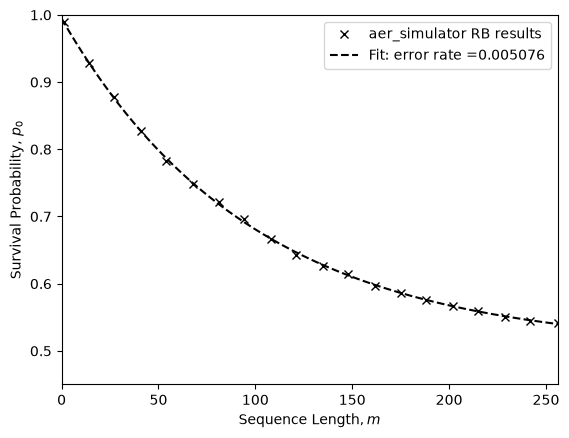

In [3]:
benchmark = CliffordRB(
    sequence_lengths=np.linspace(1, 256, 20, dtype=int),
    circuits_per_sequence_length=10,
)

benchmark(device, num_shots=4096)
result = benchmark.analyze()

print(f"Decay parameter (alpha): {result['alpha']:.6f}")
print(f"Average gate error: {result['AverageGateError']:.6f}")

For a one-qubit depolarizing channel with error probability $p$, the expected
average gate error is approximately $p / 2$. RB estimates this quantity from
the fitted decay parameter rather than from a single circuit.

Configured expected value: 0.005000
RB estimate: 0.005078


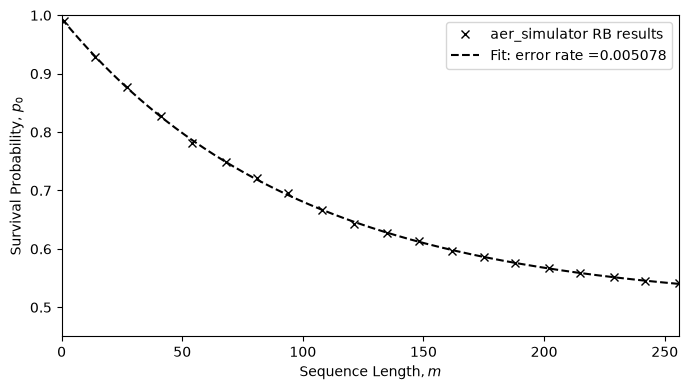

In [4]:
expected_average_gate_error = gate_error_probability / 2

print(f"Configured expected value: {expected_average_gate_error:.6f}")
print(f"RB estimate: {result['AverageGateError']:.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
benchmark.plot(ax)
fig.tight_layout()